In [139]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split
import pandas as pd

In [140]:
df = pd.read_csv(r"regression_dataset.csv")
df.head()

,X,y
0,0.102922,5.738850
1,0.171943,4.278806
2,0.232252,3.543804
3,0.290418,3.080554
4,0.325258,0.145342


In [141]:
X = df["X"]
y = df["y"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=56, shuffle=True)
X_train, X_test, y_train, y_test = np.array(X_train).reshape(-1, 1), np.array(X_test).reshape(-1, 1), np.array(y_train).reshape(-1, 1), np.array(y_test).reshape(-1, 1)

print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(40, 1)
(40, 1)
(10, 1)
(10, 1)


In [ ]:
class Locally_weighted:

    def __init__(self, gamma, max_iter=None, lr=None):
        self.max_iter = max_iter
        self.lr = lr
        self.weights = None
        self.gamma = gamma

    def fit(self, X, y):
        self.X = X
        self.y = y

        print("model fitted successfully!")

    def gussian_kernel(self, x_i, x_j):
        norm = np.linalg.norm(x_i - x_j)**2
        return np.exp(- norm / (2 * self.gamma**2))

    def predict_one(self, query):
        local_weights = np.diag([self.gussian_kernel(query, x_i) for x_i in self.X])
        self.weights = np.linalg.inv(self.X.T @ local_weights @ self.X) @ (self.X.T @ local_weights @ self.y)
        return query @ self.weights

    def predict(self, X):
        return [self.predict_one(query) for query in X]

    def __repr__(self):
        return f"Locally_weighted_Linear_regression \nmax_iter={self.max_iter}, learning_rate={self.lr}"

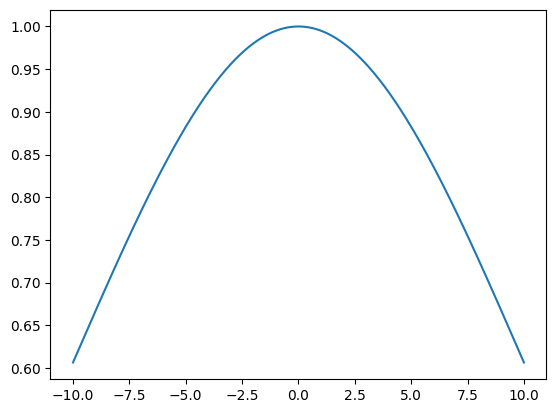

In [143]:
def gussian_kernel(x_i, x_j, gamma):
    norm = np.linalg.norm(x_i - x_j)**2
    return np.exp(- norm / (2 * gamma**2))

x = np.linspace(-10, 10, 500)
query = 0.0

y = np.array([gussian_kernel(x_i, query, 10) for x_i in x])

plt.plot(x, y);

In [144]:
model = Locally_weighted(gamma=1)

model.fit(X_train, y_train)

y_hat_train = model.predict(X_train)
y_hat_test = model.predict(X_test)

print(f"train: {r2_score(y_train, y_hat_train)}")
print(f"test: {r2_score(y_test, y_hat_test)}")

model fitted successfully!
train: 0.9615794882816324
test: 0.981067157807229


red: test-real, blue: test-predicted


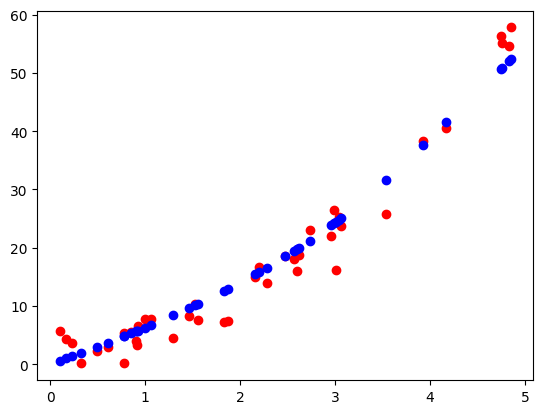

In [145]:
plt.scatter(X_train, y_train, c="red")
plt.scatter(X_train, y_hat_train, c="blue")

print("red: test-real, blue: test-predicted")

plt.show();

red: test-real, blue: test-predicted


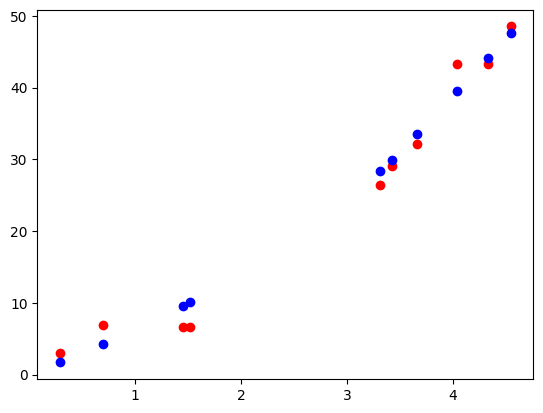

In [146]:
plt.scatter(X_test, y_test, c="red")
plt.scatter(X_test, y_hat_test, c="blue")

print("red: test-real, blue: test-predicted")

plt.show();

In [147]:
from sklearn.linear_model import LinearRegression

model2 = LinearRegression()

model2.fit(X_train, y_train)

y_hat_train = model2.predict(X_train)
y_hat_test = model2.predict(X_test)

print(f"train: {r2_score(y_train, y_hat_train)}")
print(f"test: {r2_score(y_test, y_hat_test)}")

train: 0.8932022025474208
test: 0.9405078436974208


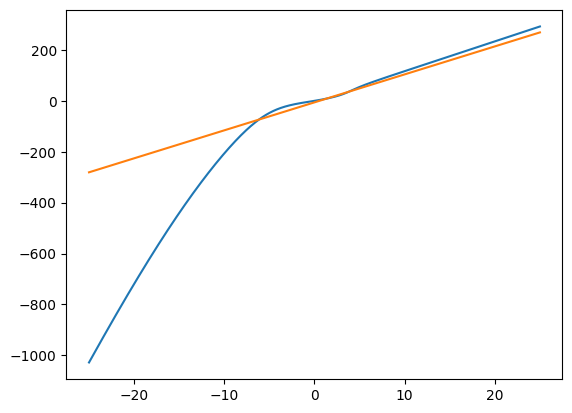

In [148]:
x = np.linspace(-25, 25, 500).reshape(-1, 1)

y_locally = model.predict(x.reshape(-1, 1))
y_linear = model2.predict(x.reshape(-1, 1))

plt.plot(x, y_locally)
plt.plot(x, y_linear)
plt.show();